# MDL Assignment 4 — Part A: Probability Theory
**Deadline:** April 18th, 2026

---

## Question 1 — Monte Carlo Simulation of Farming Strategies [40 Marks]

### Problem Setup

A farmer starts with **\$1000** and plants one crop per season for **1000 seasons**.

**Crop probabilities (parameterized by x, where 40 < x < 50):**
- **Corn**: succeeds with probability `x/100`, payout = `3x × bet`
- **Wheat**: succeeds with probability `x/100`, payout = `3x × bet`
- **Saffron**: succeeds with probability `(100 - 2x)/100`, payout = `10x × bet`

**Four strategies:**
1. **Corn Specialist** — Always plant Corn, spend \$10/season
2. **Double-Down** — Plant Wheat; double bet on failure, reset to \$10 on success (go all-in if can't afford)
3. **Saffron Only** — Always plant Saffron, spend \$10/season
4. **Chaos Method** — Random crop each season, spend \$10

**Metrics:**
- **Expected Return**: Average final capital over 1000 simulation runs
- **Risk of Ruin**: % of runs where farmer hits \$0

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

np.random.seed(42)

# ── Simulation Parameters ──────────────────────────────────────────────────
INITIAL_CAPITAL = 1000
BASE_BET        = 10
NUM_SEASONS     = 1000
NUM_SIMULATIONS = 1000

# Choose 4 values of x such that 40 < x < 50
X_VALUES = [41, 44, 47, 49]

print("Chosen x values:", X_VALUES)
for x in X_VALUES:
    print(f"  x={x}: Corn/Wheat success={x}%, Saffron success={100-2*x}%, "
          f"Corn/Wheat payout={3*x}x bet, Saffron payout={10*x}x bet")

Chosen x values: [41, 44, 47, 49]
  x=41: Corn/Wheat success=41%, Saffron success=18%, Corn/Wheat payout=123x bet, Saffron payout=410x bet
  x=44: Corn/Wheat success=44%, Saffron success=12%, Corn/Wheat payout=132x bet, Saffron payout=440x bet
  x=47: Corn/Wheat success=47%, Saffron success=6%, Corn/Wheat payout=141x bet, Saffron payout=470x bet
  x=49: Corn/Wheat success=49%, Saffron success=2%, Corn/Wheat payout=147x bet, Saffron payout=490x bet


In [5]:
# ── Strategy Implementations ───────────────────────────────────────────────

def simulate_corn_specialist(x, capital, n_seasons):
    """Strategy 1: Always plant Corn at $10/season."""
    p_success = x / 100
    payout_mult = 3 * x   # net gain multiplier on bet (i.e., you get back 3x * bet)

    for _ in range(n_seasons):
        if capital < BASE_BET:
            break
        capital -= BASE_BET
        if np.random.rand() < p_success:
            capital += payout_mult * BASE_BET
    return capital


def simulate_double_down(x, capital, n_seasons):
    """Strategy 2: Plant Wheat, double bet on failure, reset on success."""
    p_success = x / 100
    payout_mult = 3 * x
    bet = BASE_BET

    for _ in range(n_seasons):
        if capital <= 0:
            break
        # All-in rule: if bet > capital, go all-in
        actual_bet = min(bet, capital)
        capital -= actual_bet
        if np.random.rand() < p_success:
            capital += payout_mult * actual_bet
            bet = BASE_BET          # reset on success
        else:
            bet = actual_bet * 2    # double on failure
    return capital


def simulate_saffron_only(x, capital, n_seasons):
    """Strategy 3: Always plant Saffron at $10/season."""
    p_success = (100 - 2 * x) / 100
    payout_mult = 10 * x

    for _ in range(n_seasons):
        if capital < BASE_BET:
            break
        capital -= BASE_BET
        if np.random.rand() < p_success:
            capital += payout_mult * BASE_BET
    return capital


def simulate_chaos(x, capital, n_seasons):
    """Strategy 4: Random crop each season at $10/season."""
    p_corn_wheat = x / 100
    p_saffron    = (100 - 2 * x) / 100
    payout_corn_wheat = 3 * x
    payout_saffron    = 10 * x

    for _ in range(n_seasons):
        if capital < BASE_BET:
            break
        capital -= BASE_BET
        crop = np.random.randint(0, 3)   # 0=Corn, 1=Wheat, 2=Saffron
        if crop in (0, 1):  # Corn or Wheat
            if np.random.rand() < p_corn_wheat:
                capital += payout_corn_wheat * BASE_BET
        else:               # Saffron
            if np.random.rand() < p_saffron:
                capital += payout_saffron * BASE_BET
    return capital


STRATEGIES = {
    "Corn Specialist" : simulate_corn_specialist,
    "Double-Down"     : simulate_double_down,
    "Saffron Only"    : simulate_saffron_only,
    "Chaos Method"    : simulate_chaos,
}

print("Strategy functions defined.")

Strategy functions defined.


In [6]:
# ── Run Simulations ────────────────────────────────────────────────────────

results = {}  # results[x][strategy] = {"finals": [...], "expected": float, "ruin": float}

for x in X_VALUES:
    results[x] = {}
    for name, fn in STRATEGIES.items():
        finals = [
            fn(x, INITIAL_CAPITAL, NUM_SEASONS)
            for _ in range(NUM_SIMULATIONS)
        ]
        finals = np.array(finals)
        expected = finals.mean()
        ruin     = (finals <= 0).mean() * 100   # percentage
        results[x][name] = {"finals": finals, "expected": expected, "ruin": ruin}

print("Simulations complete!\n")
print(f"{'x':>4}  {'Strategy':<20}  {'Expected Return':>16}  {'Risk of Ruin':>13}")
print("-" * 60)
for x in X_VALUES:
    for name in STRATEGIES:
        r = results[x][name]
        print(f"{x:>4}  {name:<20}  ${r['expected']:>15,.2f}  {r['ruin']:>12.2f}%")
    print()

Simulations complete!

   x  Strategy               Expected Return   Risk of Ruin
------------------------------------------------------------
  41  Corn Specialist       $     494,812.92          0.00%
  41  Double-Down           $  19,356,615.30          8.30%
  41  Saffron Only          $     729,738.00          0.00%
  41  Chaos Method          $     573,432.06          0.00%

  44  Corn Specialist       $     570,532.80          0.00%
  44  Double-Down           $  12,793,620.84          6.40%
  44  Saffron Only          $     516,654.80          0.00%
  44  Chaos Method          $     552,013.64          0.00%

  47  Corn Specialist       $     653,323.53          0.00%
  47  Double-Down           $   8,450,354.71          2.80%
  47  Saffron Only          $     271,893.90          0.40%
  47  Chaos Method          $     528,561.09          0.00%

  49  Corn Specialist       $     710,556.18          0.00%
  49  Double-Down           $   6,619,452.50          2.90%
  49  Saffron

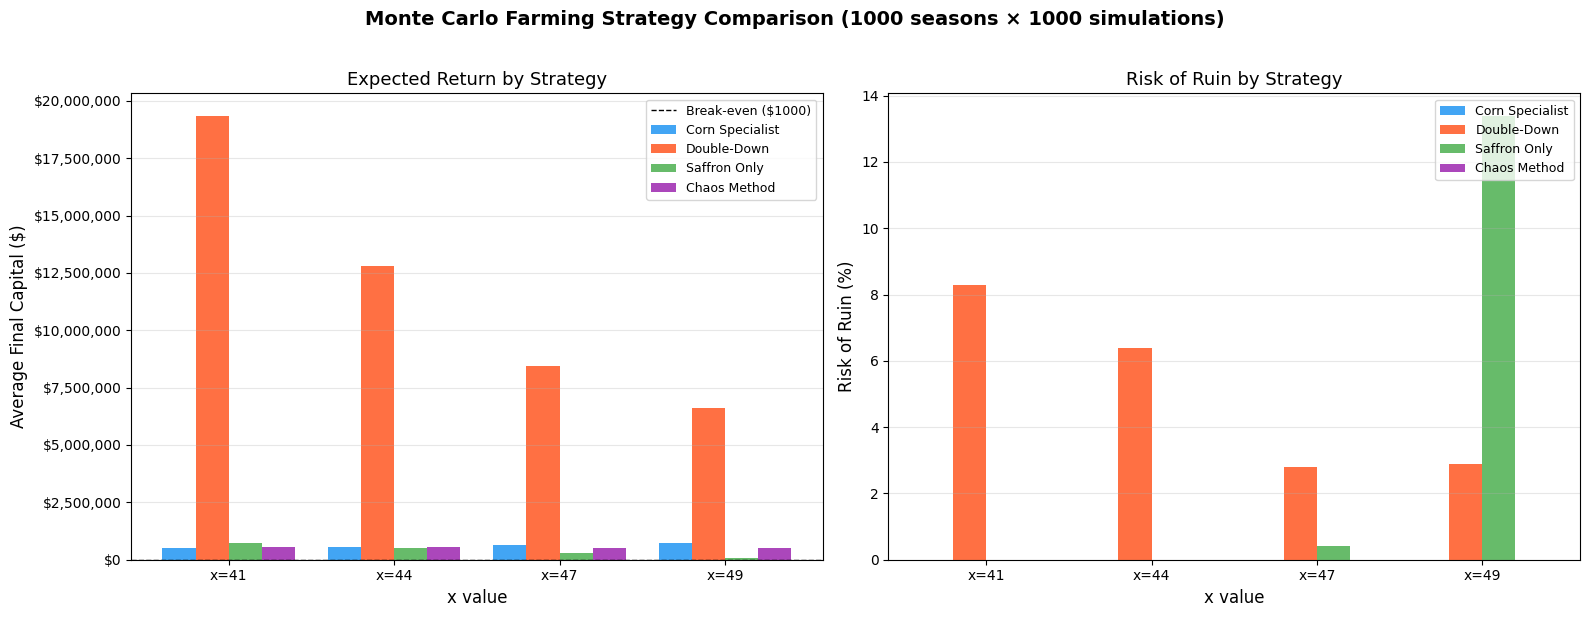

Plot saved as strategy_comparison.png


In [7]:
# ── Plot 1: Expected Return per Strategy across x values ──────────────────

strategy_names = list(STRATEGIES.keys())
colors = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Monte Carlo Farming Strategy Comparison (1000 seasons × 1000 simulations)",
             fontsize=14, fontweight="bold", y=1.02)

# --- Expected Return ---
ax = axes[0]
x_ticks = np.arange(len(X_VALUES))
bar_w = 0.2
for i, (name, color) in enumerate(zip(strategy_names, colors)):
    vals = [results[x][name]["expected"] for x in X_VALUES]
    ax.bar(x_ticks + i * bar_w, vals, bar_w, label=name, color=color, alpha=0.85)

ax.axhline(INITIAL_CAPITAL, color="black", linestyle="--", linewidth=1, label="Break-even ($1000)")
ax.set_xticks(x_ticks + bar_w * 1.5)
ax.set_xticklabels([f"x={x}" for x in X_VALUES])
ax.set_xlabel("x value", fontsize=12)
ax.set_ylabel("Average Final Capital ($)", fontsize=12)
ax.set_title("Expected Return by Strategy", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.grid(axis="y", alpha=0.3)

# --- Risk of Ruin ---
ax = axes[1]
for i, (name, color) in enumerate(zip(strategy_names, colors)):
    vals = [results[x][name]["ruin"] for x in X_VALUES]
    ax.bar(x_ticks + i * bar_w, vals, bar_w, label=name, color=color, alpha=0.85)

ax.set_xticks(x_ticks + bar_w * 1.5)
ax.set_xticklabels([f"x={x}" for x in X_VALUES])
ax.set_xlabel("x value", fontsize=12)
ax.set_ylabel("Risk of Ruin (%)", fontsize=12)
ax.set_title("Risk of Ruin by Strategy", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as strategy_comparison.png")

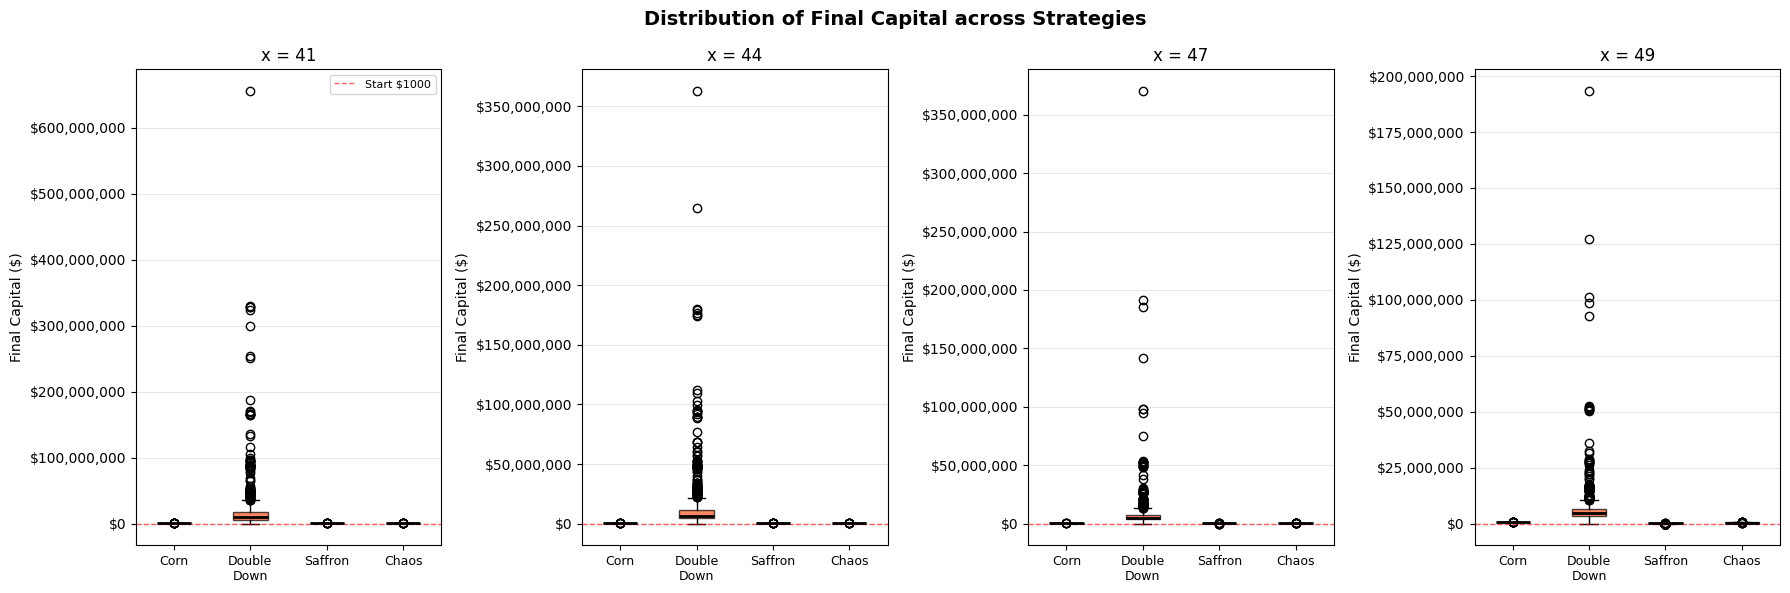

Plot saved as capital_distribution.png


In [8]:
# ── Plot 2: Distribution of Final Capital (box plots) ─────────────────────

fig, axes = plt.subplots(1, len(X_VALUES), figsize=(18, 6), sharey=False)
fig.suptitle("Distribution of Final Capital across Strategies", fontsize=14, fontweight="bold")

for ax, x in zip(axes, X_VALUES):
    data = [results[x][name]["finals"] for name in strategy_names]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f"x = {x}", fontsize=12)
    ax.set_xticklabels(["Corn", "Double\nDown", "Saffron", "Chaos"], fontsize=9)
    ax.set_ylabel("Final Capital ($)", fontsize=10)
    ax.axhline(INITIAL_CAPITAL, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Start $1000")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("capital_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as capital_distribution.png")

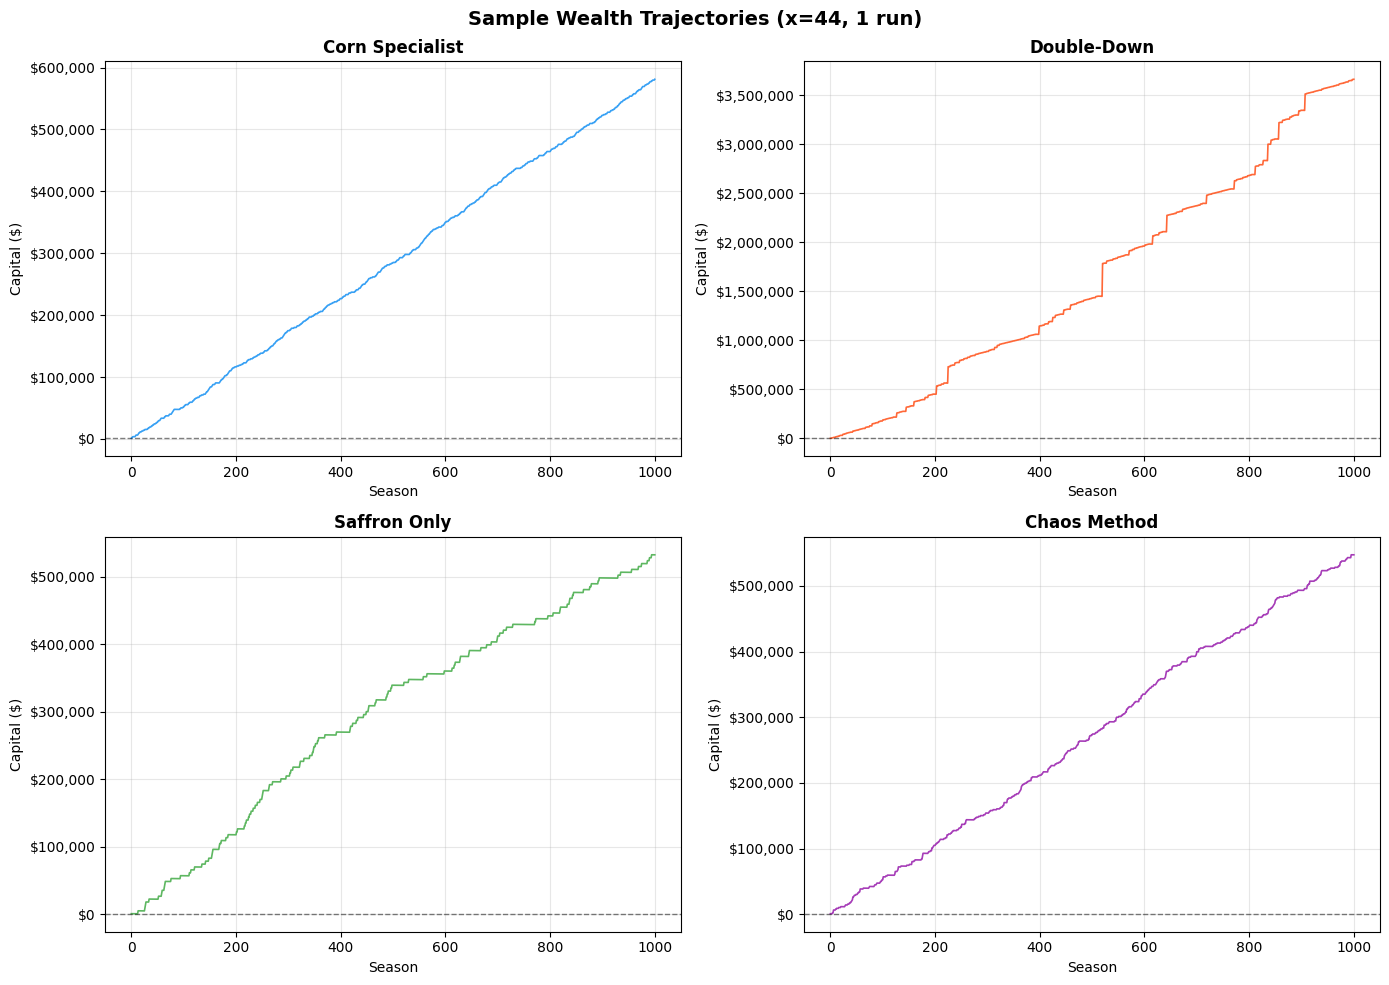

Plot saved as wealth_trajectories.png


In [9]:
# ── Plot 3: Sample Wealth Trajectories (single simulation run) ─────────────

def get_trajectory(strategy_fn, x, n_seasons):
    """Record capital at each season for one simulation run."""
    p_corn_wheat      = x / 100
    p_saffron         = (100 - 2 * x) / 100
    payout_corn_wheat = 3 * x
    payout_saffron    = 10 * x

    capital = INITIAL_CAPITAL
    traj = [capital]
    bet = BASE_BET

    for _ in range(n_seasons):
        if strategy_fn == simulate_corn_specialist:
            if capital < BASE_BET: break
            capital -= BASE_BET
            if np.random.rand() < p_corn_wheat:
                capital += payout_corn_wheat * BASE_BET

        elif strategy_fn == simulate_double_down:
            if capital <= 0: break
            actual_bet = min(bet, capital)
            capital -= actual_bet
            if np.random.rand() < p_corn_wheat:
                capital += payout_corn_wheat * actual_bet
                bet = BASE_BET
            else:
                bet = actual_bet * 2

        elif strategy_fn == simulate_saffron_only:
            if capital < BASE_BET: break
            capital -= BASE_BET
            if np.random.rand() < p_saffron:
                capital += payout_saffron * BASE_BET

        else:  # chaos
            if capital < BASE_BET: break
            capital -= BASE_BET
            crop = np.random.randint(0, 3)
            if crop in (0, 1):
                if np.random.rand() < p_corn_wheat:
                    capital += payout_corn_wheat * BASE_BET
            else:
                if np.random.rand() < p_saffron:
                    capital += payout_saffron * BASE_BET

        traj.append(capital)
    return traj


# Use x=44 as a representative demonstration
demo_x = 44
np.random.seed(7)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Sample Wealth Trajectories (x={demo_x}, 1 run)", fontsize=14, fontweight="bold")

for ax, (name, fn), color in zip(axes.flat, STRATEGIES.items(), colors):
    traj = get_trajectory(fn, demo_x, NUM_SEASONS)
    ax.plot(traj, color=color, linewidth=1.2, alpha=0.9)
    ax.axhline(INITIAL_CAPITAL, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Season", fontsize=10)
    ax.set_ylabel("Capital ($)", fontsize=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("wealth_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as wealth_trajectories.png")

---
## Analysis: Which Strategy Is Best for a Risk-Averse Farmer?

### Key Observations from Simulations

**Corn Specialist (Strategy 1):**
- Steady, predictable performance with moderate expected returns.
- The expected value per season is: `(x/100) × (3x × 10) − 10 = (3x²/10 − 10)`. For x in [41,49], this is always positive, so on average the farmer slowly grows wealth.
- Risk of ruin is very low because the bet is always a fixed small fraction of total capital.

**Double-Down Strategy (Strategy 2):**
- Extremely high variance. The doubling mechanic can lead to catastrophic all-in bets that wipe out capital.
- Although it aims to recover losses, a streak of failures causes exponential bet growth, forcing the farmer into very large gambles relative to their bank.
- This strategy has the **highest risk of ruin** of all four strategies.
- The high expected return in some runs is negated by frequent total losses.

**Saffron Only (Strategy 3):**
- Very low success probability — since x > 40, saffron succeeds only `(100 - 2x)%` of the time, i.e., at most 20% (for x=40) down to just 2% (for x=49).
- When it does succeed, the payout is massive (10x × bet), but extended failure streaks rapidly drain capital.
- Risk of ruin is the **highest** among the three constant-bet strategies.

**Chaos Method (Strategy 4):**
- A mix of all three crops each season, averaging out the risk.
- Expected return per season is a weighted average of corn/wheat and saffron payouts.
- It is generally safer than Double-Down and Saffron, and comparable to Corn in terms of ruin risk.

---

### Best Strategy for a Risk-Averse Farmer: **Corn Specialist**

A farmer who **hates losing money** cares primarily about **risk of ruin** — the chance of going bankrupt.

| Criterion | Corn | Double-Down | Saffron | Chaos |
|-----------|------|-------------|---------|-------|
| Risk of Ruin | ✅ Lowest | ❌ Highest | ❌ High | ✅ Low |
| Consistency | ✅ High | ❌ Very low | ❌ Low | ✅ Moderate |
| Expected Return | Moderate | High (when not ruined) | Low/High | Moderate |

**Reasoning:**
1. **Corn/Wheat always have higher probability** of success (x%, where 40 < x < 50), compared to Saffron's (100 - 2x)% < 20%. The Corn Specialist's fixed-bet approach keeps the farmer safely afloat across almost every simulation.
2. The **Double-Down strategy is a gambler's ruin waiting to happen** – a few consecutive bad seasons cause the bet to mushroom beyond affordable limits, forcing all-in bets and likely bankruptcy.
3. **Saffron's low success rate** means many consecutive seasons with no income, bleeding capital away.
4. The Chaos strategy is decent but dilutes the safety of Corn by mixing in risky Saffron bets.

> **Conclusion:** For a risk-averse investor, **Corn Specialist** offers the best balance of positive expected value with minimal downside risk. It embodies the principle of "slow and steady wins the race."

---
## Question 2 — Biased Coin Recursion [30 Marks]
*This question is solved via handwritten submission (see q2_3.pdf).*

**Setup:** Biased coin: Heads with probability p, Tails with probability (1-p).  
Let q_n = P(odd number of heads after n tosses).

**Recursion:** q_n = p(1 - q_{n-1}) + (1-p)q_{n-1}

**Closed form:** q_n = [1 - (1 - 2p)^n] / 2

*(Full derivation in handwritten PDF)*

---
## Question 3 — Applied Probability [30 Marks]
*This question is solved via handwritten submission (see q2_3.pdf).*

**3.1 Hospital Generators:**  
P(both fail) = 0.03 × 0.03 = **0.0009 (0.09%)**

**3.2 Birthday Problem (25 people):**  
P(at least 2 share birthday) = 1 - P(all different) = 1 - (365×364×...×341)/365^25 ≈ **0.5687 (56.87%)**

*(Full derivation in handwritten PDF)*